# System Analysis

A modular, single-system analysis notebook. Edit the **System Configuration** cell to switch
between the four target systems; every subsequent section adapts automatically.

**Four questions addressed:**
1. How do observed signals change over time? — Sections 1–2
2. How do different input patterns affect the observations? — Sections 3–6
3. Are some signals more informative than others? — Section 7
4. What is easy to observe, and what seems hidden? — Sections 8–9

> **To explore a different system:** uncomment exactly one constructor in the *System Configuration* cell.
> Every cell below reads from `sim` and adapts automatically.

In [20]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, '.')

from Simulator import (
    Simulator, default_neural_system,
    input_aligned_system, input_blind_system,
    slow_drift_system, closed_loop_system,
    zero_input, pulse_input, sinusoidal_input,
    random_input, channel_sweep_input,
    controllability_matrix, observability_matrix, matrix_rank,
)
from Illustrator import Illustrator

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## System Configuration

Uncomment **exactly one** constructor. All sections below adapt automatically.

| System | Design hypothesis |
|--------|------------------|
| `input_aligned_system` | First two neurons directly track input-driven state dims — a privileged observer |
| `input_blind_system` | No neuron directly observes input-driven dims — input effect arrives only via slow coupling |
| `slow_drift_system` | A near-random-walk mode (A[2,2]=0.999) creates low-frequency drift that challenges estimation |
| `closed_loop_system` | Input-aligned readout + amplified drive (2×B) — high-SNR, high-reactivity regime |

In [21]:
# Choose which system to analyse. Uncomment exactly one.
# sim = input_aligned_system(seed=42, obs_dim=16)
sim = input_blind_system(seed=42, obs_dim=16)
# sim = slow_drift_system(seed=42, obs_dim=16)
# sim = closed_loop_system(seed=42, obs_dim=16)

# Optionally also leave default available for sanity-checking:
# sim = default_neural_system(seed=42, obs_dim=16)

T        = 120   # timesteps per trial
R_trials = 30    # number of independent trials

print(f'System: state_dim={sim.state_dim}, input_dim={sim.input_dim}, obs_dim={sim.obs_dim}')
print(f'T={T}, R_trials={R_trials}')

System: state_dim=4, input_dim=2, obs_dim=16
T=120, R_trials=30


---
## 1  Meet the System

Before running any simulation, inspect the mathematical skeleton.
**A** sets oscillation frequencies and decay rates; **C** projects hidden states into
neurons; column norms of **C** reveal which state dimensions are directly visible;
the observability Gramian spectrum quantifies how easily each mode can be recovered.

In [22]:
print('=== Dimensions ===')
print(f'  state_dim={sim.state_dim},  input_dim={sim.input_dim},  obs_dim={sim.obs_dim}')
print()
print('=== State transition matrix A ===')
print(np.round(sim.A, 4))
print()
print('=== Input matrix B ===')
print(np.round(sim.B, 4))
nrows = min(4, sim.obs_dim)
print()
print(f'=== Observation matrix C (first {nrows} of {sim.obs_dim} rows) ===')
print(np.round(sim.C[:nrows], 4))
print()
print('=== Column norms of C (sensitivity per latent state) ===')
col_norms = np.linalg.norm(sim.C, axis=0)
for i, cn in enumerate(col_norms):
    note = '  <-- ZERO: observations are blind to this state' if cn < 1e-10 else ''
    print(f'  ||C[:,{i}]|| = {cn:.4f}{note}')
print()
print('=== Eigenvalues of A ===')
eigvals_A = np.linalg.eigvals(sim.A)
for i, lam in enumerate(eigvals_A):
    mag   = abs(lam)
    angle = np.angle(lam)
    if abs(angle) > 1e-10:
        period_val = abs(2 * np.pi / angle)
        desc = f'period ~ {period_val:.1f} steps  (oscillatory)'
    else:
        hl = np.log(0.5) / np.log(mag) if 0 < mag < 1 else float('inf')
        desc = f'half-life ~ {hl:.1f} steps  (pure decay)'
    print(f'  lam{i} = {lam.real:+.4f}{lam.imag:+.4f}j   |lam| = {mag:.4f}   {desc}')
print()
print(f'All |lam| < 1 (stable): {np.all(np.abs(eigvals_A) < 1)}')
print()

# Auto-detect natural oscillation period — used in Sections 4, 7, 8
osc = eigvals_A[(np.abs(eigvals_A.imag) > 1e-10) & (eigvals_A.imag > 0)]
if len(osc) > 0:
    nat_period     = int(round(abs(2 * np.pi / np.angle(osc[0]))))
    has_oscillator = True
    print(f'Natural oscillation period (auto-detected): ~{nat_period} steps')
else:
    nat_period     = T // 4
    has_oscillator = False
    print(f'No oscillatory modes detected. Fallback period = T//4 = {nat_period} steps.')

=== Dimensions ===
  state_dim=4,  input_dim=2,  obs_dim=16

=== State transition matrix A ===
[[ 0.9225 -0.2997  0.      0.    ]
 [ 0.2997  0.9225  0.      0.    ]
 [ 0.05    0.      0.98    0.    ]
 [ 0.      0.05    0.      0.75  ]]

=== Input matrix B ===
[[1.  0. ]
 [0.  1. ]
 [0.5 0. ]
 [0.  0.5]]

=== Observation matrix C (first 4 of 16 rows) ===
[[ 0.      0.      0.7505  0.9406]
 [ 0.      0.      0.1278 -0.3162]
 [ 0.      0.      0.8794  0.7778]
 [ 0.      0.      0.4675 -0.8593]]

=== Column norms of C (sensitivity per latent state) ===
  ||C[:,0]|| = 0.0000  <-- ZERO: observations are blind to this state
  ||C[:,1]|| = 0.0000  <-- ZERO: observations are blind to this state
  ||C[:,2]|| = 3.4713
  ||C[:,3]|| = 2.5579

=== Eigenvalues of A ===
  lam0 = +0.9800+0.0000j   |lam| = 0.9800   half-life ~ 34.3 steps  (pure decay)
  lam1 = +0.7500+0.0000j   |lam| = 0.7500   half-life ~ 2.4 steps  (pure decay)
  lam2 = +0.9225+0.2997j   |lam| = 0.9700   period ~ 20.0 steps  (oscillat

=== Controllability ===
  rank = 4 / 4  -->  FULLY CONTROLLABLE

=== Observability ===
  rank = 4 / 4  -->  FULLY OBSERVABLE


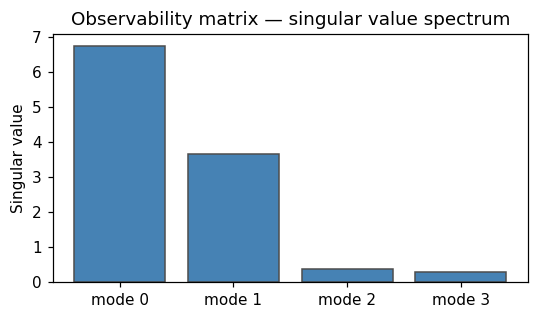

Condition number: 22.89  (larger -> some modes harder to recover)


In [23]:
Wc     = controllability_matrix(sim.A, sim.B)
Wo     = observability_matrix(sim.A, sim.C)
rank_c = matrix_rank(Wc)
rank_o = matrix_rank(Wo)

print('=== Controllability ===')
print(f'  rank = {rank_c} / {sim.state_dim}  -->  {"FULLY CONTROLLABLE" if rank_c == sim.state_dim else "NOT FULLY CONTROLLABLE"}')
print()
print('=== Observability ===')
print(f'  rank = {rank_o} / {sim.state_dim}  -->  {"FULLY OBSERVABLE" if rank_o == sim.state_dim else "NOT FULLY OBSERVABLE"}')

_, s_obs, _ = np.linalg.svd(Wo)
n = sim.state_dim
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(range(n), s_obs[:n], color='steelblue', edgecolor='0.3')
ax.set_xticks(range(n))
ax.set_xticklabels([f'mode {i}' for i in range(n)])
ax.set_ylabel('Singular value')
ax.set_title('Observability matrix — singular value spectrum')
plt.tight_layout()
plt.show()
cond = s_obs[0] / s_obs[n - 1] if s_obs[n - 1] > 0 else float('inf')
print(f'Condition number: {cond:.2f}  (larger -> some modes harder to recover)')

**What to notice:**
- Each complex-conjugate eigenvalue pair corresponds to an oscillatory mode; real
  eigenvalues are pure decay. The magnitude `|lam|` sets the decay per step.
- Column norms of **C** flag state dimensions that are invisible to the observations.
  For `input_blind_system` columns 0 and 1 are zero, so the oscillatory modes driven
  by B can only leak into observations indirectly through A's off-diagonal coupling.
- *Fully observable* is a binary guarantee for infinite noiseless data. The singular
  value spectrum (observability Gramian) quantifies how easily each mode is recovered
  in practice — a large condition number means some directions are close to unobservable.

---
## 2  Free Dynamics — Zero Input

**Question 1: How do observed signals change over time?**

Run the system from its initial condition with no input. This isolates A's contribution:
the state decays and oscillates purely according to the eigenstructure above, and
the observations inherit those timescales through C.

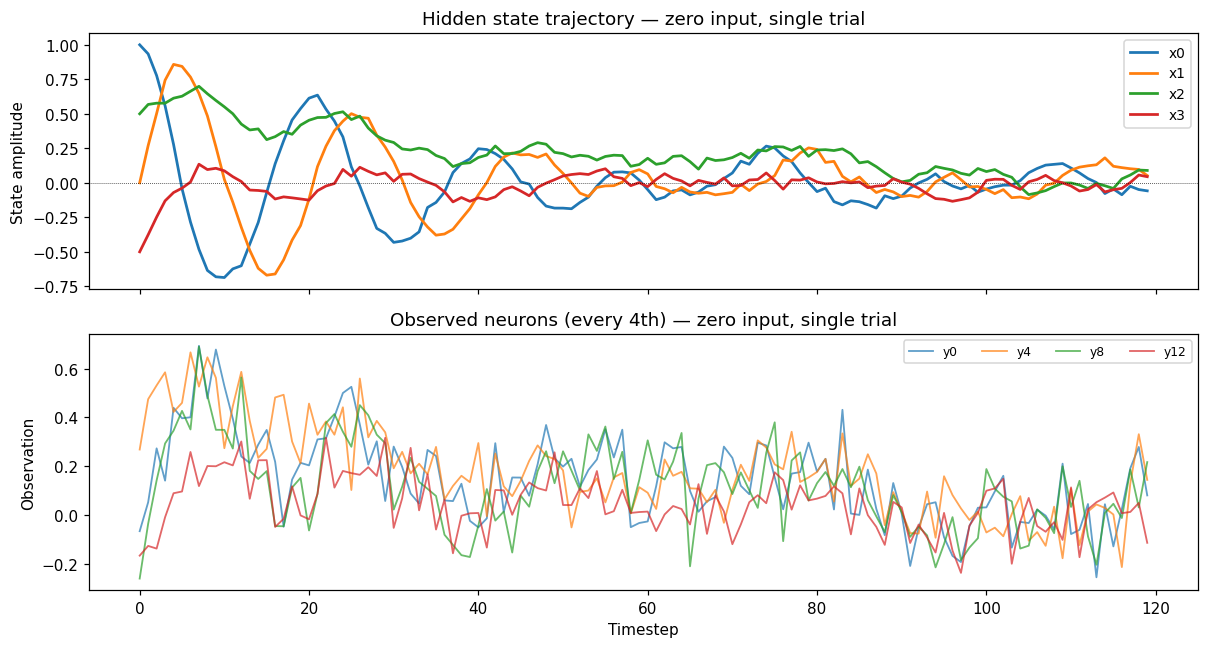

In [24]:
U_zero      = zero_input(T, sim.input_dim)
result_zero = sim.simulate(T, U=U_zero)
x_zero      = result_zero['x'][:-1]   # (T, state_dim)
y_zero_1    = result_zero['y']         # (T, obs_dim) — single trial

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

for i in range(sim.state_dim):
    axes[0].plot(x_zero[:, i], label=f'x{i}', linewidth=1.8)
axes[0].set_ylabel('State amplitude')
axes[0].set_title('Hidden state trajectory — zero input, single trial')
axes[0].legend(fontsize=9)
axes[0].axhline(0, color='k', lw=0.5, ls=':')

step = max(1, sim.obs_dim // 4)
for ni in range(0, sim.obs_dim, step):
    axes[1].plot(y_zero_1[:, ni], alpha=0.7, lw=1.2, label=f'y{ni}')
axes[1].set_ylabel('Observation')
axes[1].set_xlabel('Timestep')
axes[1].set_title(f'Observed neurons (every {step}th) — zero input, single trial')
axes[1].legend(fontsize=8, ncol=4)
plt.tight_layout()
plt.show()

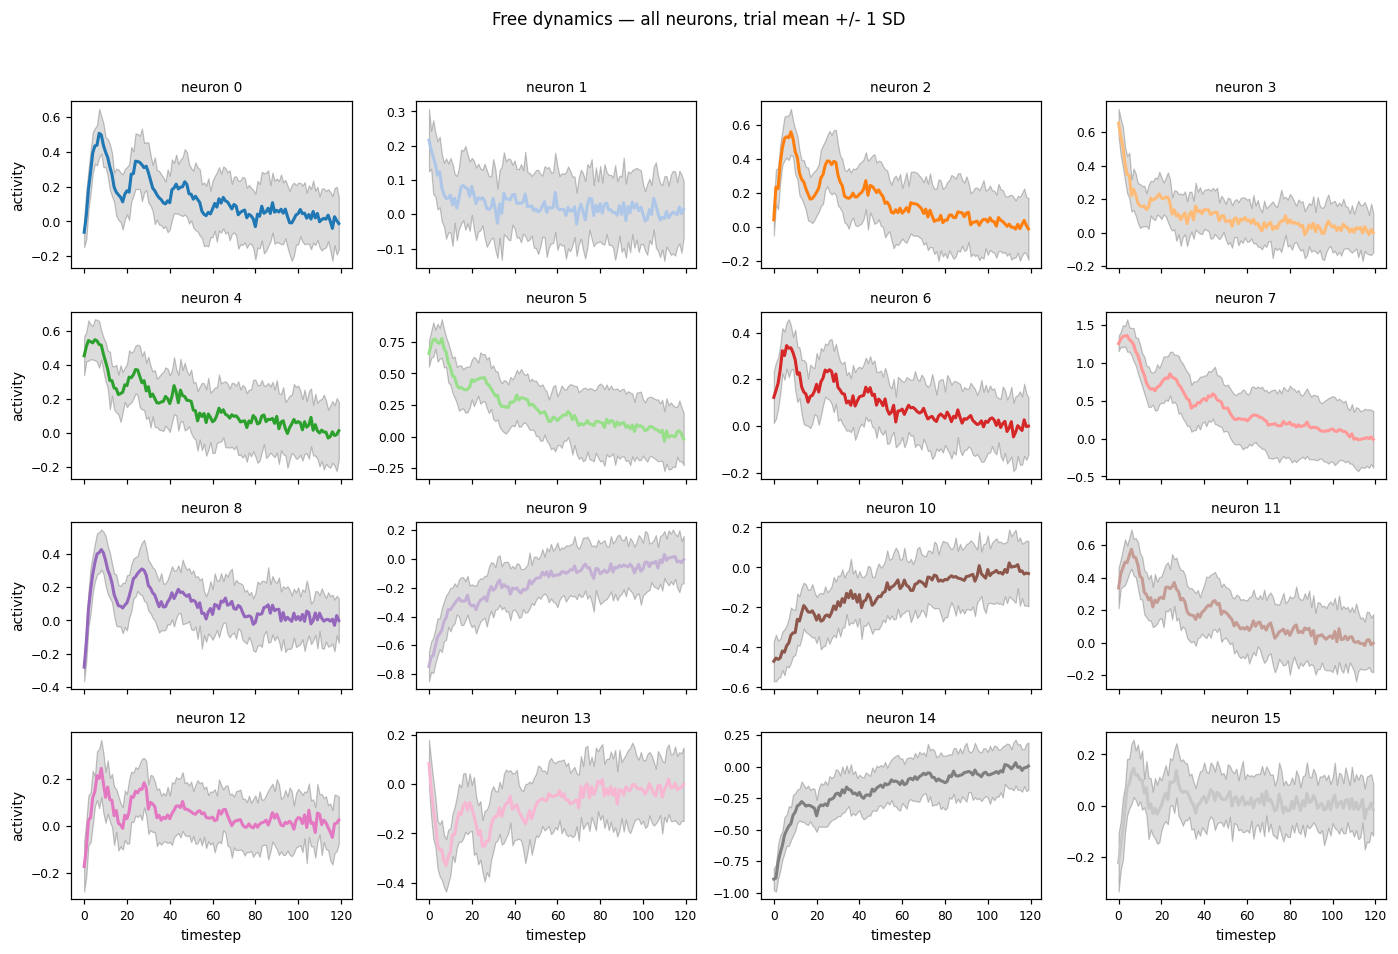

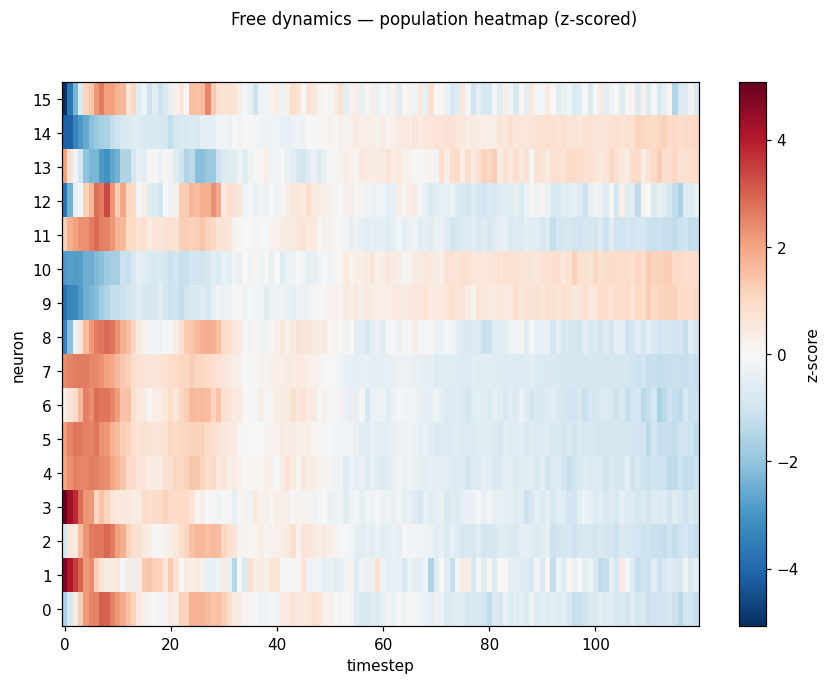

C:\Users\sassa\AppData\Local\Temp\ipykernel_36012\3401275093.py:13: UserWarning: max_lag=40 exceeds T//4=30; the longest lag uses only 80 pairs per trial and the tail of the ACF may be unreliable.
  fig = ill_zero.plot_autocorrelation(max_lag=max_lag, mode='heatmap',


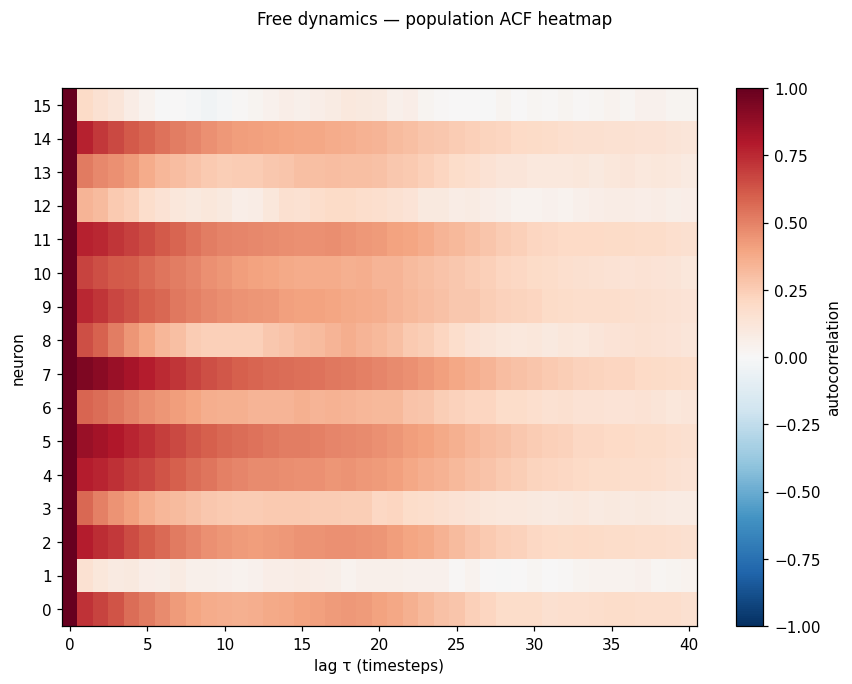

C:\Users\sassa\AppData\Local\Temp\ipykernel_36012\3401275093.py:18: UserWarning: max_lag=40 exceeds T//4=30; the longest lag uses only 80 pairs per trial and the tail of the ACF may be unreliable.
  fig = ill_zero.plot_autocorrelation(max_lag=max_lag, mode='overlay',


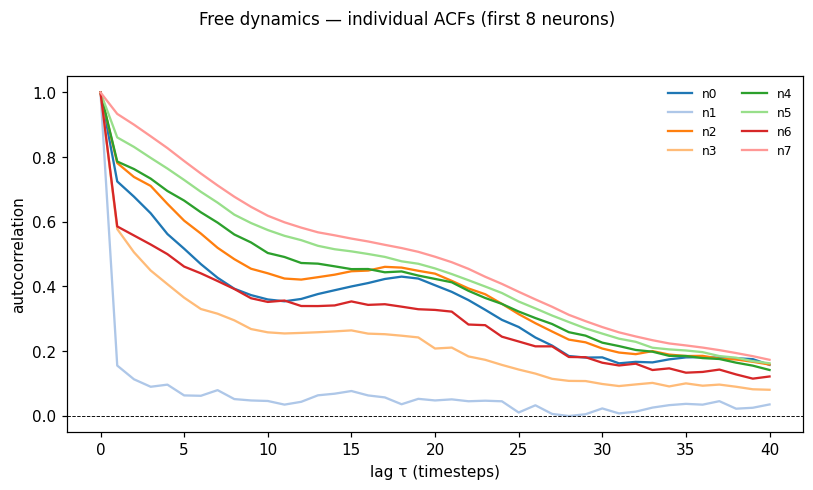

In [25]:
trials_zero = sim.simulate_trials(R_trials, T, U=U_zero)
ill_zero    = Illustrator(trials_zero['y'])

fig = ill_zero.plot_timeseries(show_trials=False,
                               title='Free dynamics — all neurons, trial mean +/- 1 SD')
plt.show()

fig = ill_zero.plot_heatmap(zscore=True,
                            title='Free dynamics — population heatmap (z-scored)')
plt.show()

max_lag = min(40, T // 3)
fig = ill_zero.plot_autocorrelation(max_lag=max_lag, mode='heatmap',
                                    title='Free dynamics — population ACF heatmap')
plt.show()

n_acf = min(8, sim.obs_dim)
fig = ill_zero.plot_autocorrelation(max_lag=max_lag, mode='overlay',
                                    neuron_indices=np.arange(n_acf),
                                    title=f'Free dynamics — individual ACFs (first {n_acf} neurons)')
plt.show()

**What to notice:**
- Any oscillatory modes appear as sinusoidal ripples in the state and as damped cosines
  in the ACF; pure decay modes produce a monotone exponential tail.
- All neurons share the same fundamental timescales — diversity across neurons reflects
  different weights in C (amplitude and phase), not different frequencies.
- The fast-decaying mode vanishes early; its contribution is visible only in the first
  few timesteps before the slower dynamics dominate.
- For `slow_drift_system`, watch for a low-frequency drift that does not decay within
  the trial window — this is the near-unit-root A[2,2]=0.999 mode.

---
## 3  Pulse Input — Transient Response

**Question 2: How do different input patterns affect the observations?**

A brief kick at t=10 deposits energy into the state. The system then rings at its
natural frequencies. Comparing channel 0 vs channel 1 reveals which neurons each
input pathway preferentially recruits, as set by the columns of B projected through C.

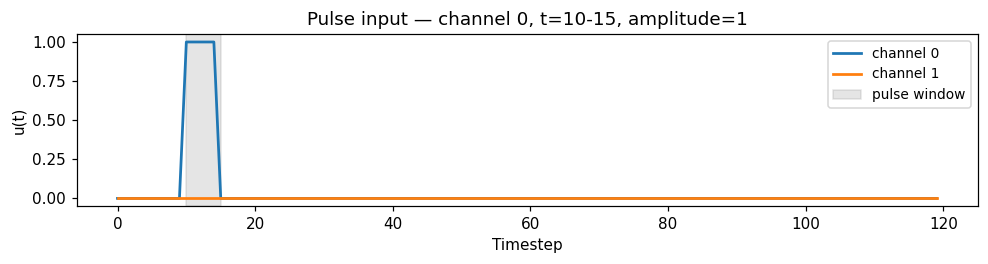

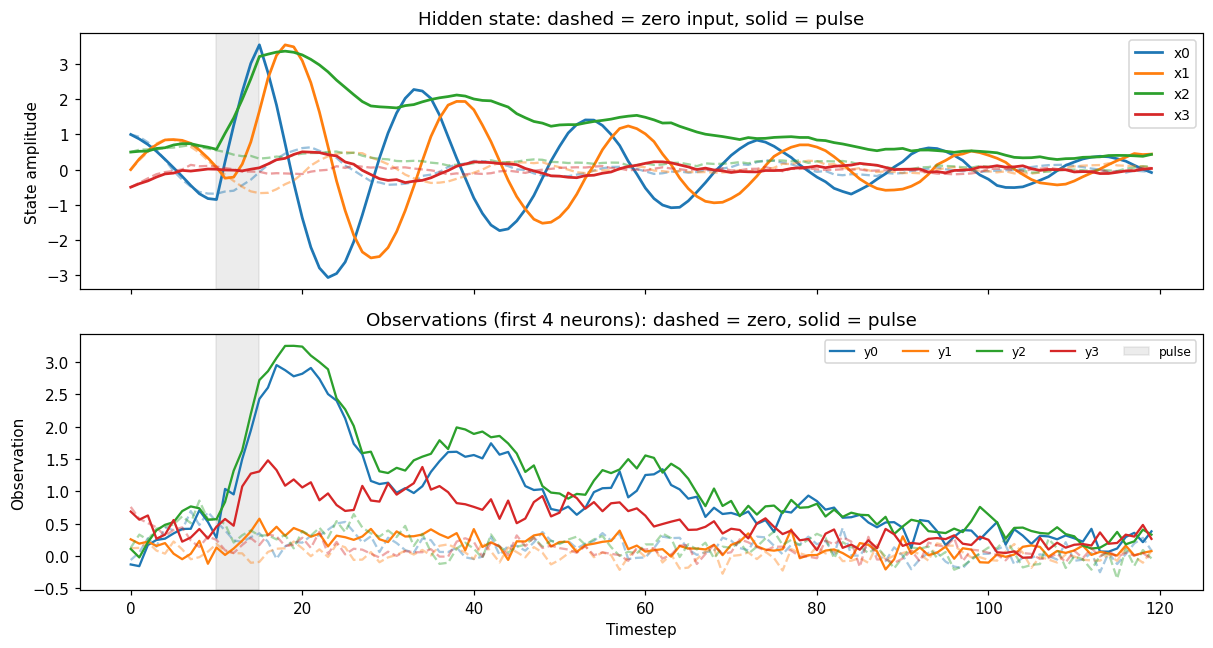

In [26]:
U_pulse = pulse_input(T, sim.input_dim, channel=0, start=10, duration=5, amplitude=1.0)

fig, ax = plt.subplots(figsize=(9, 2.5))
for ch in range(sim.input_dim):
    ax.plot(U_pulse[:, ch], label=f'channel {ch}', lw=1.8)
ax.axvspan(10, 15, color='gray', alpha=0.2, label='pulse window')
ax.set_xlabel('Timestep')
ax.set_ylabel('u(t)')
ax.set_title('Pulse input — channel 0, t=10-15, amplitude=1')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

result_pulse_1 = sim.simulate(T, U=U_pulse)
x_pulse        = result_pulse_1['x'][:-1]

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for i in range(sim.state_dim):
    axes[0].plot(x_zero[:, i],  ls='--', alpha=0.45, color=f'C{i}')
    axes[0].plot(x_pulse[:, i], lw=1.8,              color=f'C{i}', label=f'x{i}')
axes[0].axvspan(10, 15, color='gray', alpha=0.15)
axes[0].set_ylabel('State amplitude')
axes[0].set_title('Hidden state: dashed = zero input, solid = pulse')
axes[0].legend(fontsize=9)

ns = min(4, sim.obs_dim)
for ni in range(ns):
    axes[1].plot(y_zero_1[:, ni],            ls='--', alpha=0.4, color=f'C{ni}')
    axes[1].plot(result_pulse_1['y'][:, ni], lw=1.5,             color=f'C{ni}', label=f'y{ni}')
axes[1].axvspan(10, 15, color='gray', alpha=0.15, label='pulse')
axes[1].set_ylabel('Observation')
axes[1].set_xlabel('Timestep')
axes[1].set_title(f'Observations (first {ns} neurons): dashed = zero, solid = pulse')
axes[1].legend(fontsize=8, ncol=ns + 1)
plt.tight_layout()
plt.show()

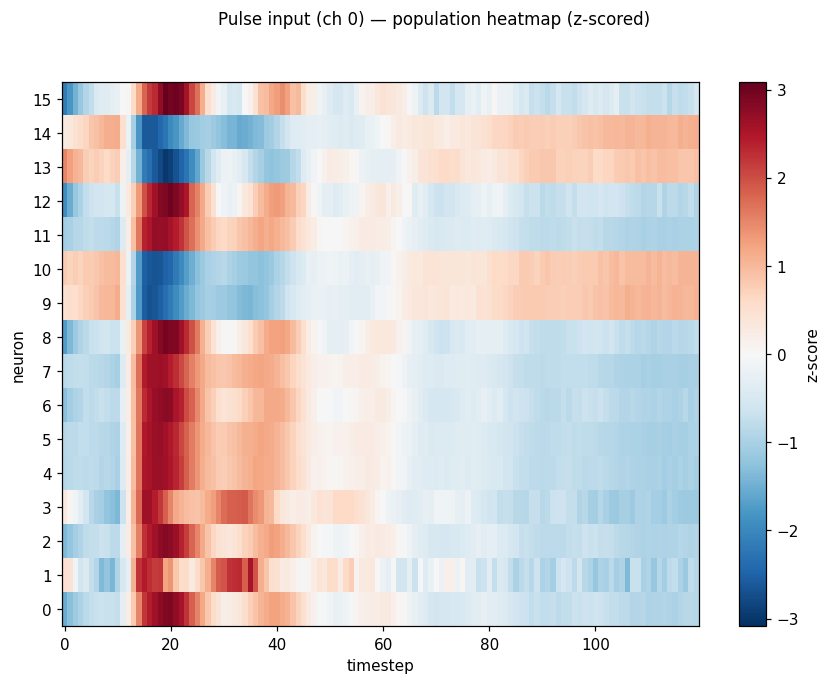

In [27]:
trials_pulse = sim.simulate_trials(R_trials, T, U=U_pulse)
ill_pulse    = Illustrator(trials_pulse['y'])

fig = ill_pulse.plot_heatmap(zscore=True,
                             title='Pulse input (ch 0) — population heatmap (z-scored)')
plt.show()

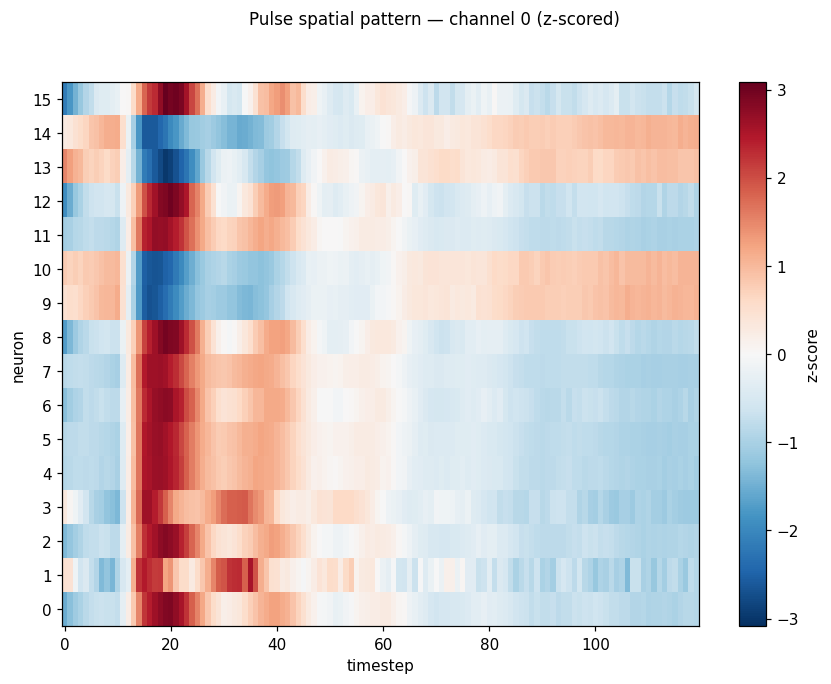

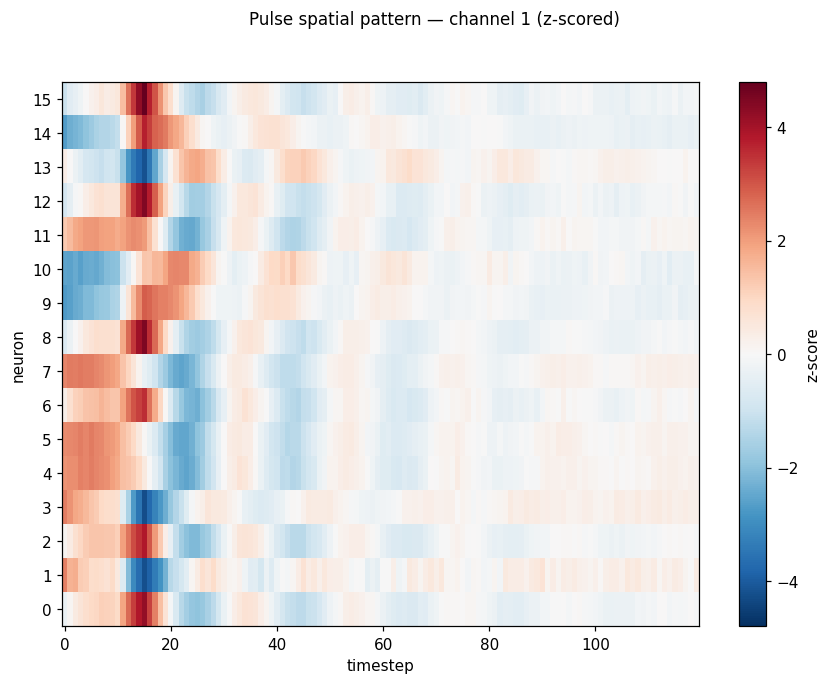

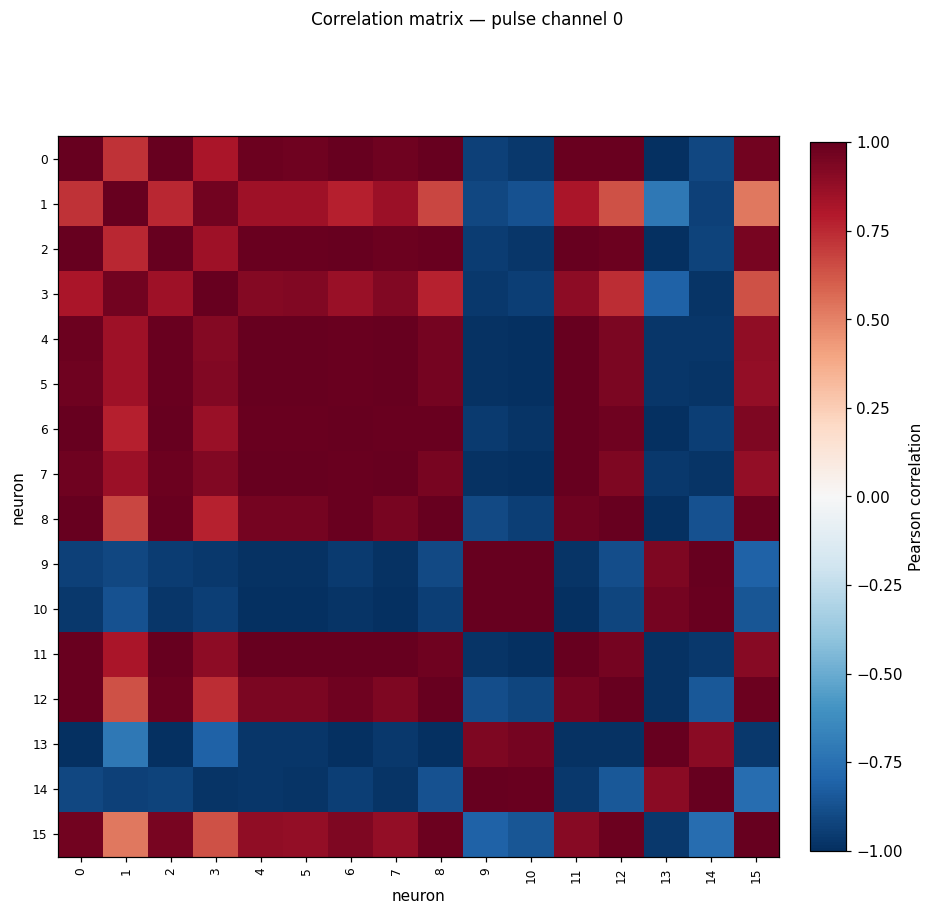

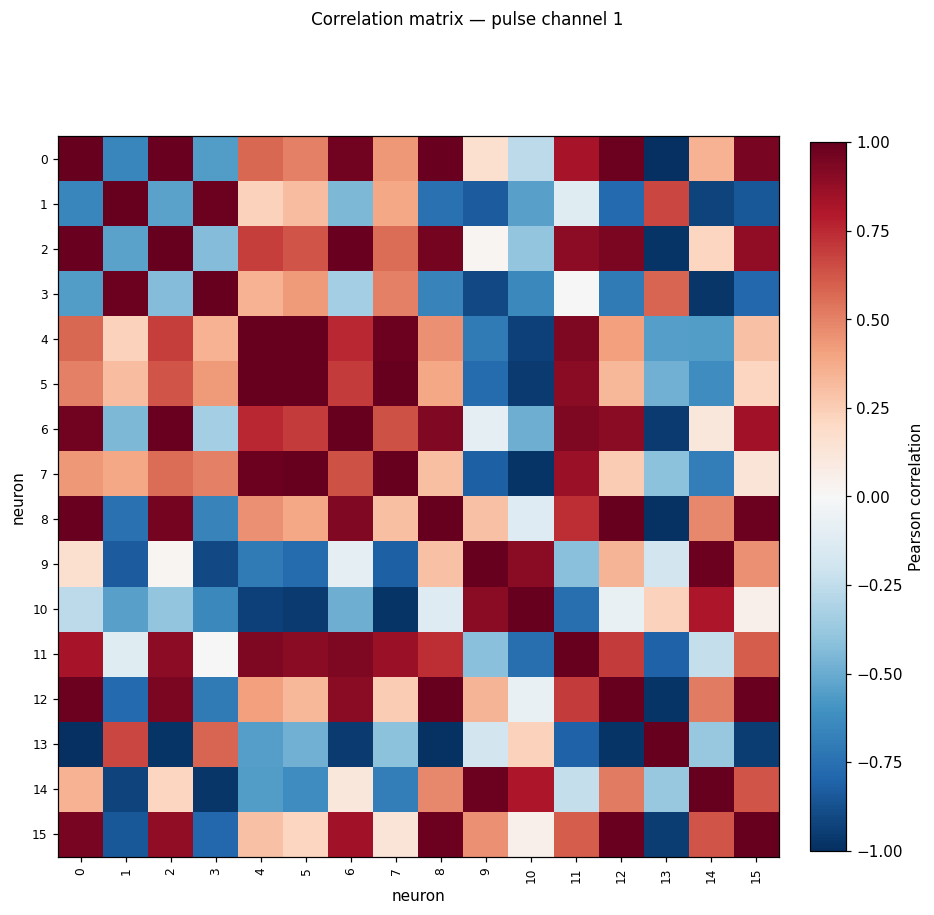

In [28]:
if sim.input_dim > 1:
    U_pulse_ch1   = pulse_input(T, sim.input_dim, channel=1, start=10, duration=5)
    trials_pulse1 = sim.simulate_trials(R_trials, T, U=U_pulse_ch1)
    ill_pulse_ch1 = Illustrator(trials_pulse1['y'])

    fig = ill_pulse.plot_heatmap(zscore=True,
                                 title='Pulse spatial pattern — channel 0 (z-scored)')
    plt.show()

    fig = ill_pulse_ch1.plot_heatmap(zscore=True,
                                     title='Pulse spatial pattern — channel 1 (z-scored)')
    plt.show()

    C0, fig0 = ill_pulse.plot_correlation_matrix(cluster=False,
                                                  title='Correlation matrix — pulse channel 0')
    plt.show()

    C1, fig1 = ill_pulse_ch1.plot_correlation_matrix(cluster=False,
                                                      title='Correlation matrix — pulse channel 1')
    plt.show()
else:
    print('Only one input channel — skipping channel comparison.')

**What to notice:**
- After the pulse, oscillatory modes ring on at the natural period; slowly-decaying
  modes carry excitation for many steps after the pulse ends.
- Channels 0 and 1 produce different spatial patterns across neurons because their
  respective columns of B project through C differently.
- Despite different spatial patterns, both channels often produce similar correlation
  structure — correlation normalises out amplitude, leaving only co-movement, which
  is set by the shared latent modes.
- For `input_blind_system`, the pulse response in y will be delayed and attenuated
  because the input can only reach y indirectly through A's small off-diagonal terms.

---
## 4  Sinusoidal Input — Resonance and Frequency Dependence

**Question 2 (continued): How do different input patterns affect the observations?**

Driving the system at its natural oscillation frequency produces the largest steady-state
response — resonance. Off-resonance inputs produce smaller responses, and the ACF reveals
a superposition of the input period and the system's natural period.

Oscillatory modes detected. Natural period = 20 steps.
Comparing resonant, 2x-slower, and 3x-faster sinusoidal inputs.


C:\Users\sassa\AppData\Local\Temp\ipykernel_36012\1727426011.py:32: UserWarning: max_lag=50 exceeds T//4=30; the longest lag uses only 70 pairs per trial and the tail of the ACF may be unreliable.
  fig = ill.plot_autocorrelation(max_lag=min(50, T // 2), mode='overlay',


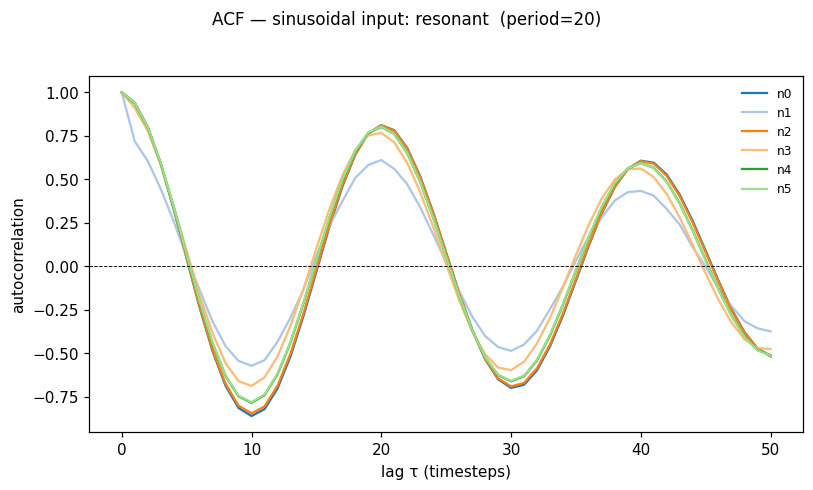

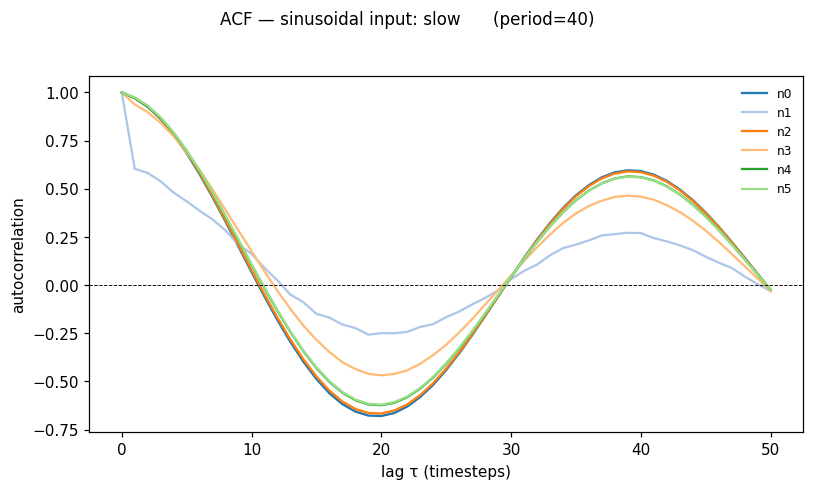

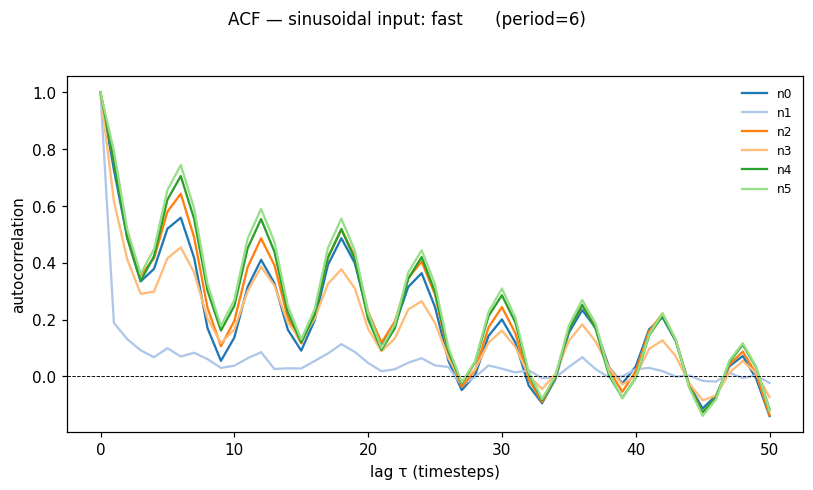

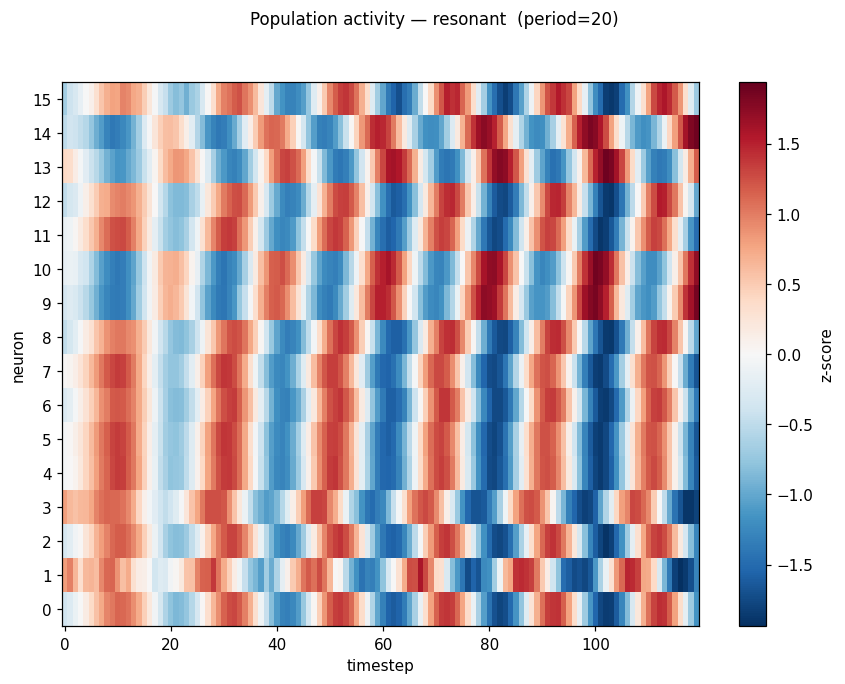

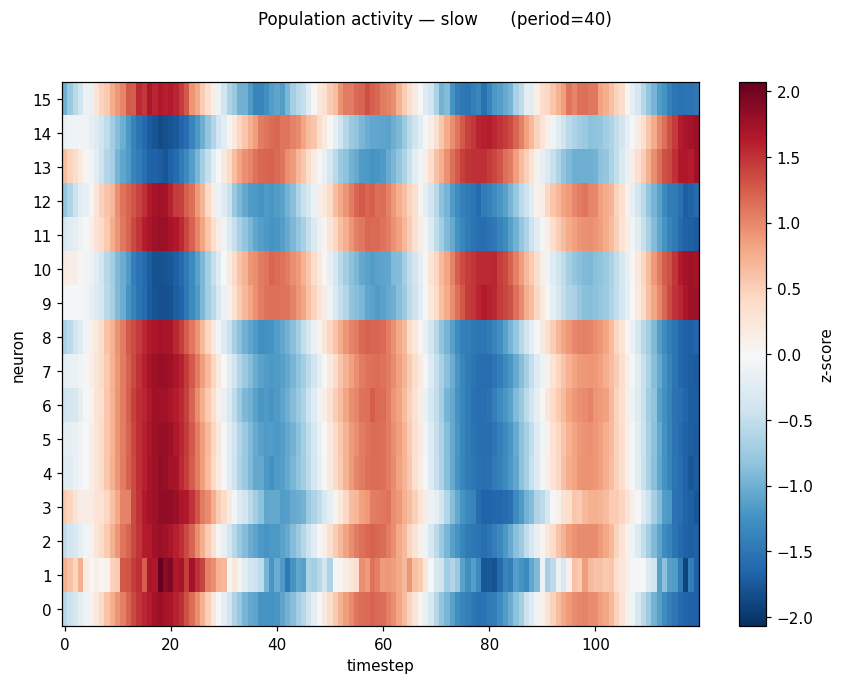

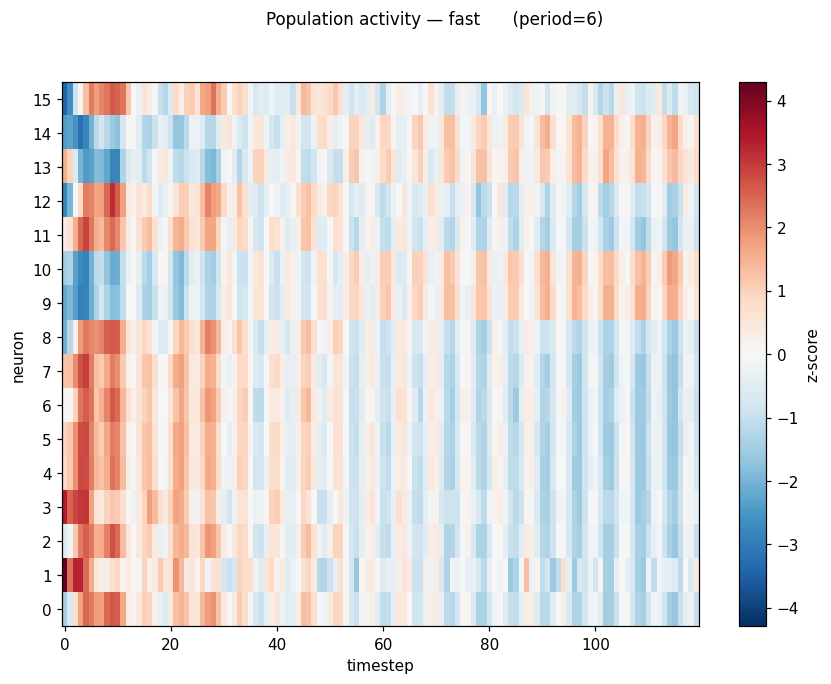

In [29]:
if has_oscillator:
    p_slow = nat_period * 2
    p_fast = max(4, nat_period // 3)
    sin_specs = [
        (f'resonant  (period={nat_period})', float(nat_period)),
        (f'slow      (period={p_slow})',     float(p_slow)),
        (f'fast      (period={p_fast})',     float(p_fast)),
    ]
    print(f'Oscillatory modes detected. Natural period = {nat_period} steps.')
    print('Comparing resonant, 2x-slower, and 3x-faster sinusoidal inputs.')
else:
    p_slow = T // 2
    p_mid  = T // 4
    p_fast = max(4, T // 8)
    sin_specs = [
        (f'slow (period={p_slow})', float(p_slow)),
        (f'mid  (period={p_mid})',  float(p_mid)),
        (f'fast (period={p_fast})', float(p_fast)),
    ]
    print('No oscillatory modes detected — comparing three arbitrary frequencies (no resonance framing).')

n_sin_trials = 20
n_acf_show   = min(6, sim.obs_dim)
illustrators_sin = {}

for label, period in sin_specs:
    U_s    = sinusoidal_input(T, sim.input_dim, amplitude=0.5, period=period)
    trials = sim.simulate_trials(n_sin_trials, T, U=U_s)
    ill    = Illustrator(trials['y'])
    illustrators_sin[label] = ill

    fig = ill.plot_autocorrelation(max_lag=min(50, T // 2), mode='overlay',
                                   neuron_indices=np.arange(n_acf_show),
                                   title=f'ACF — sinusoidal input: {label}')
    plt.show()

for label, ill in illustrators_sin.items():
    fig = ill.plot_heatmap(zscore=True, title=f'Population activity — {label}')
    plt.show()

**What to notice:**
- On-resonance drive (if applicable) produces the largest steady-state amplitude;
  A amplifies frequencies near its natural pole without producing unbounded growth.
- The ACF under each input shows a superposition of the input period and the system's
  natural period. Under resonant drive they coincide into a single dominant peak.
- For systems with no oscillatory modes, amplitude varies smoothly across frequencies
  with no resonance peak — the system acts more like a low-pass filter.
- Trial-to-trial variability (band width) is set by noise, not input; a weaker response
  (off-resonance) sits lower above the noise floor, reducing effective SNR.

---
## 5  Random Input — The System as a Filter

**Question 2 (continued) + Question 3: Random inputs and signal quality**

Broadband random (white-noise) input stimulates all frequencies equally. The system
then acts as a resonant filter, imprinting its eigenstructure on the output. The ACF
of y under white-noise drive reveals the system's impulse-response fingerprint regardless
of which specific input was used.

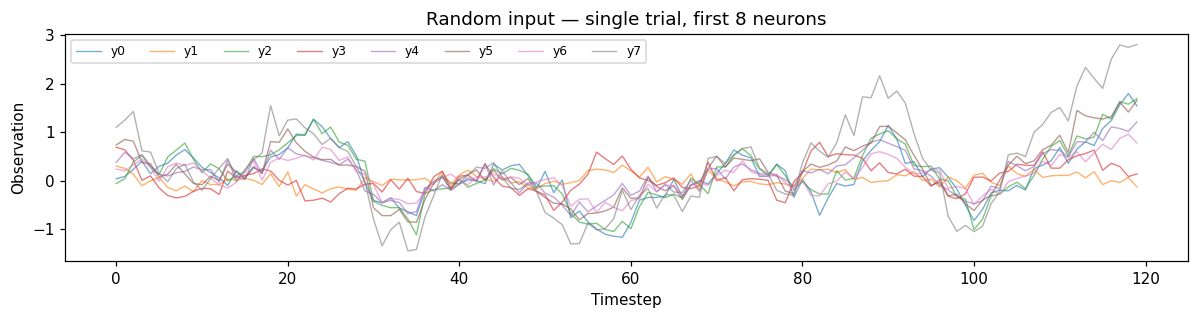

C:\Users\sassa\AppData\Local\Temp\ipykernel_36012\3344969298.py:18: UserWarning: max_lag=50 exceeds T//4=30; the longest lag uses only 70 pairs per trial and the tail of the ACF may be unreliable.
  fig = ill_rand.plot_autocorrelation(max_lag=min(50, T // 2), mode='heatmap',


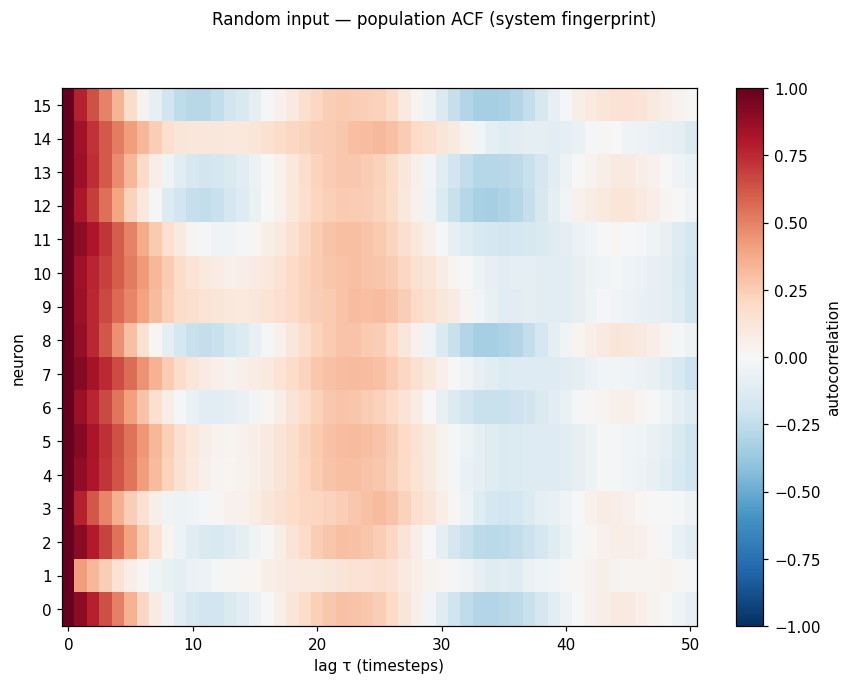

In [30]:
U_rand        = random_input(T, sim.input_dim, amplitude=0.3, seed=99)
result_rand_1 = sim.simulate(T, U=U_rand)

n_rand = min(8, sim.obs_dim)
fig, ax = plt.subplots(figsize=(11, 3))
for ni in range(n_rand):
    ax.plot(result_rand_1['y'][:, ni], alpha=0.6, lw=0.9, label=f'y{ni}')
ax.set_xlabel('Timestep')
ax.set_ylabel('Observation')
ax.set_title(f'Random input — single trial, first {n_rand} neurons')
ax.legend(fontsize=8, ncol=n_rand)
plt.tight_layout()
plt.show()

trials_rand = sim.simulate_trials(R_trials, T, U=U_rand)
ill_rand    = Illustrator(trials_rand['y'])

fig = ill_rand.plot_autocorrelation(max_lag=min(50, T // 2), mode='heatmap',
                                    title='Random input — population ACF (system fingerprint)')
plt.show()

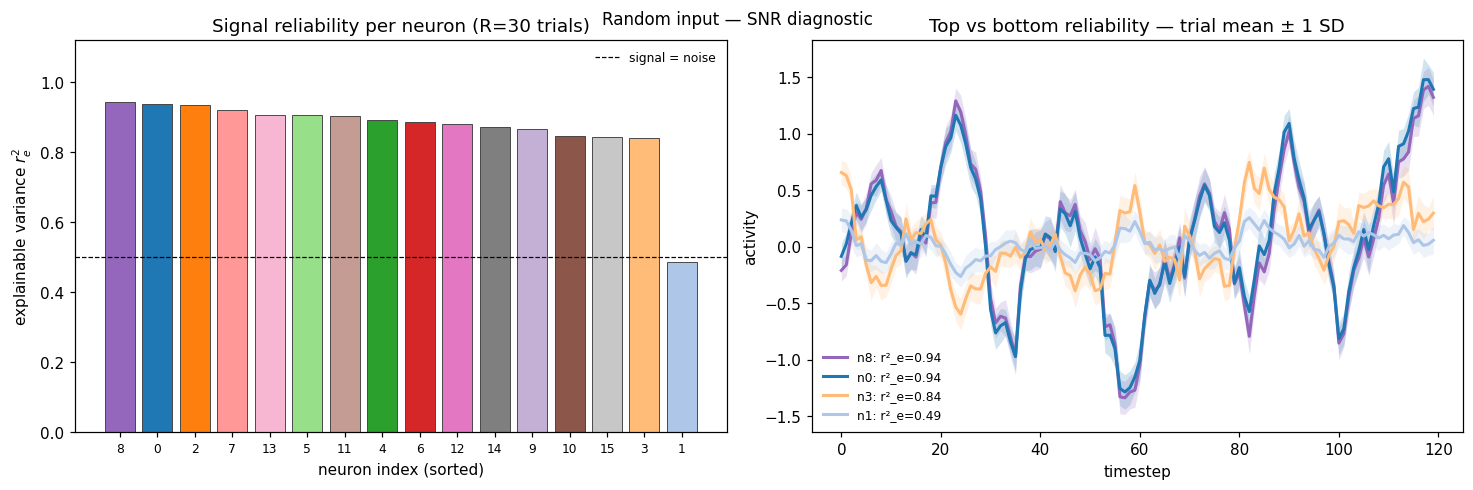

SNR range : 0.948 - 16.556
Neurons with SNR > 1 : 15 / 16


In [31]:
snr_rand, fig = ill_rand.compute_snr(plot=True)
fig.suptitle('Random input — SNR diagnostic', fontsize=11)
plt.show()

snr_finite = snr_rand[~np.isnan(snr_rand)]
print(f'SNR range : {snr_finite.min():.3f} - {snr_finite.max():.3f}')
print(f'Neurons with SNR > 1 : {(snr_finite > 1).sum()} / {sim.obs_dim}')

**What to notice:**
- Even under broadband white-noise drive, the ACF still shows the natural oscillation
  period — the system's resonance is a property of A, independent of input spectrum.
- SNR is generally *lower* than under pulse or sinusoidal input because signal power
  is spread across all frequencies rather than concentrated.
- This reflects a real experimental trade-off: broadband inputs are good for system
  *identification* (all modes excited), but reduce per-neuron SNR for any one mode.
- For `input_blind_system`, the SNR under random input will be low across the board —
  the input effect must travel two hops before reaching the observations.

---
## 6  Channel-Specific Probes — Input Pathway Fingerprinting

**Question 2 (continued): Activating channels individually and with different amplitudes**

Activating one input channel at a time reveals which neurons each pathway preferentially
recruits. This is a channel sweep: channel k is active during its allocated window,
all others silent. The grouped bar chart is the actionable fingerprint — it shows at a
glance which neurons lie downstream of each input pathway.

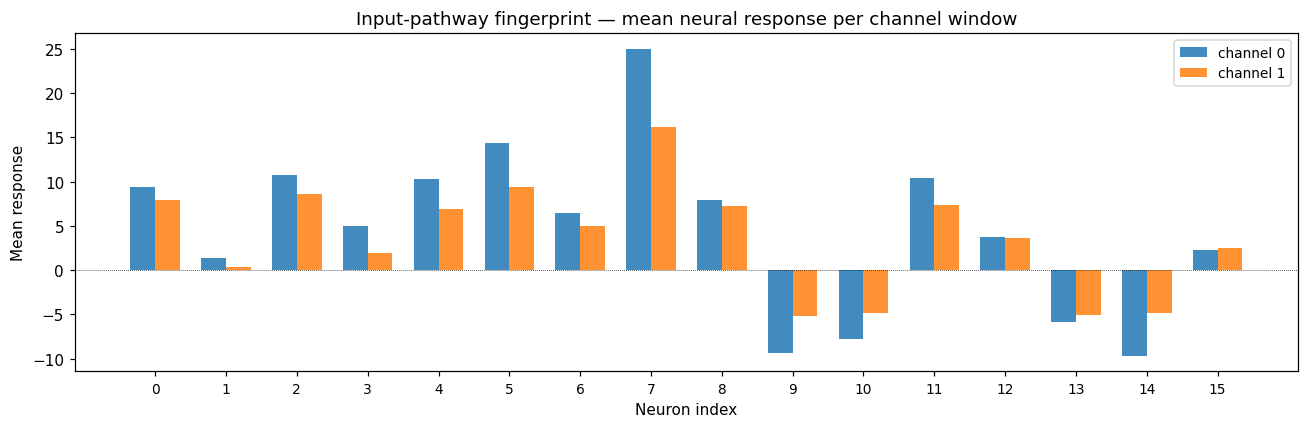

In [32]:
U_sweep      = channel_sweep_input(T, sim.input_dim, amplitude=1.0)
trials_sweep = sim.simulate_trials(25, T, U=U_sweep)

n_ch  = sim.input_dim
edges = np.linspace(0, T, n_ch + 1, dtype=int)

mean_per_channel = np.array([
    trials_sweep['y'][:, edges[k]:edges[k + 1], :].mean(axis=(0, 1))
    for k in range(n_ch)
])   # (n_ch, obs_dim)

neurons = np.arange(sim.obs_dim)
width   = 0.7 / n_ch
fig, ax = plt.subplots(figsize=(12, 4))
for k in range(n_ch):
    ax.bar(neurons + k * width, mean_per_channel[k], width,
           label=f'channel {k}', alpha=0.85)
ax.set_xticks(neurons + width * (n_ch - 1) / 2)
ax.set_xticklabels([str(n) for n in neurons], fontsize=9)
ax.set_xlabel('Neuron index', fontsize=10)
ax.set_ylabel('Mean response', fontsize=10)
ax.set_title('Input-pathway fingerprint — mean neural response per channel window')
ax.legend(fontsize=9)
ax.axhline(0, color='k', lw=0.5, ls=':')
plt.tight_layout()
plt.show()

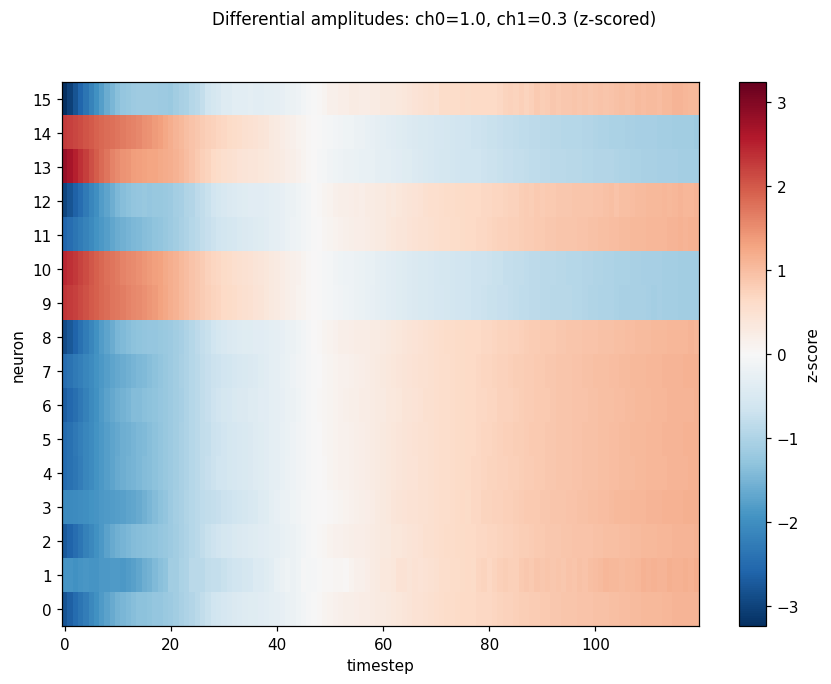

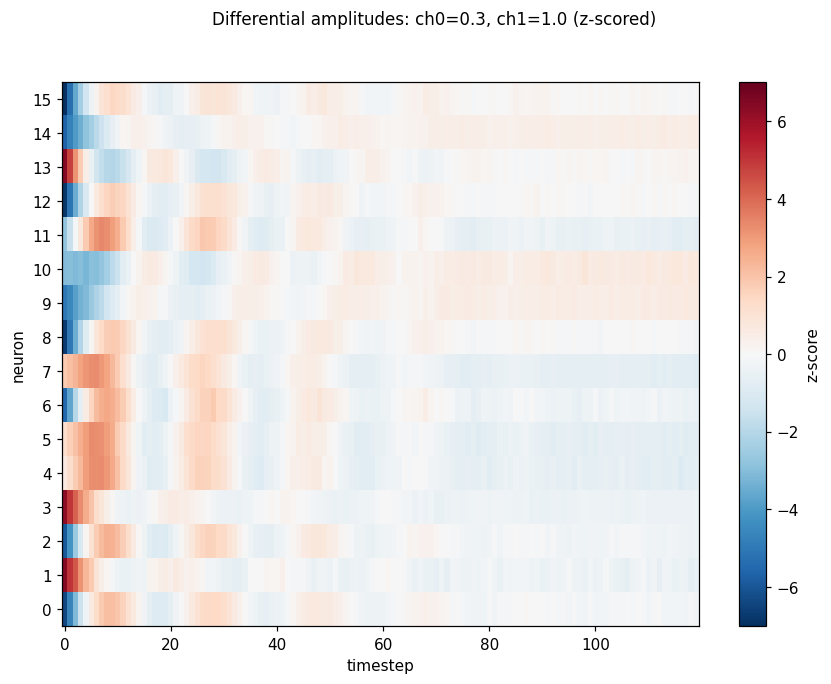

In [33]:
if sim.input_dim >= 2:
    amp_hi = 1.0
    amp_lo = 0.3

    U_v1 = np.zeros((T, sim.input_dim))
    U_v1[:, 0] = amp_hi
    U_v1[:, 1] = amp_lo

    U_v2 = np.zeros((T, sim.input_dim))
    U_v2[:, 0] = amp_lo
    U_v2[:, 1] = amp_hi

    trials_v1 = sim.simulate_trials(R_trials, T, U=U_v1)
    trials_v2 = sim.simulate_trials(R_trials, T, U=U_v2)
    ill_v1    = Illustrator(trials_v1['y'])
    ill_v2    = Illustrator(trials_v2['y'])

    fig = ill_v1.plot_heatmap(zscore=True,
                               title=f'Differential amplitudes: ch0={amp_hi}, ch1={amp_lo} (z-scored)')
    plt.show()

    fig = ill_v2.plot_heatmap(zscore=True,
                               title=f'Differential amplitudes: ch0={amp_lo}, ch1={amp_hi} (z-scored)')
    plt.show()
else:
    print('Only one input channel — amplitude ratio comparison requires input_dim >= 2.')

**What to notice:**
- Each channel recruits a distinguishable neural subset; the bar heights are the
  spatial fingerprint of the B-column projected through C.
- This fingerprint is fixed by the system matrices — it does not change across input
  conditions, only its amplitude does.
- Swapping the amplitude ratio between channels shifts which subset dominates the
  heatmap, directly demonstrating how input structure shapes observed population activity.
- For `input_aligned_system` and `closed_loop_system`, neurons 0 and 1 should show
  especially clean, channel-specific responses because their C rows are aligned with B.T.

---
## 7  Signal Quality — Per-Neuron SNR Across Input Conditions

**Question 3: Are some signals more informative than others?**

The Sahani-Linden bias-corrected SNR separates trial-to-trial signal variance from
noise variance, with a correction term that subtracts the expected noise leakage
into the trial average. Comparing SNR across all four input conditions reveals which
neurons are reliably informative and under what drive.

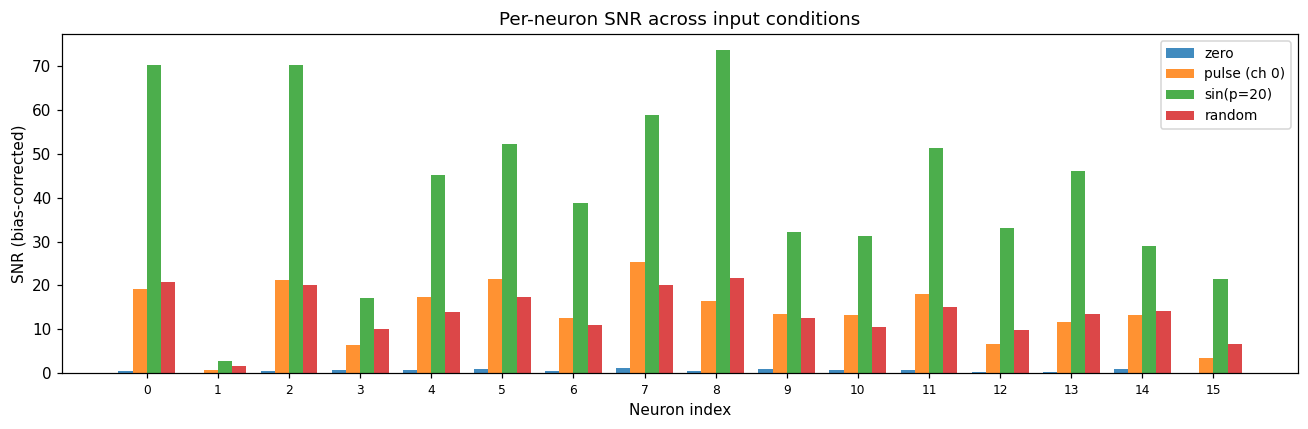

In [34]:
snr_conditions = {
    'zero':              zero_input(T, sim.input_dim),
    'pulse (ch 0)':      pulse_input(T, sim.input_dim, channel=0, start=10, duration=5),
    f'sin(p={nat_period})': sinusoidal_input(T, sim.input_dim, amplitude=0.5,
                                              period=float(nat_period)),
    'random':            random_input(T, sim.input_dim, amplitude=0.3, seed=0),
}

snr_by_cond = {}
for name, U_c in snr_conditions.items():
    t_ = sim.simulate_trials(R_trials, T, U=U_c)
    ill_ = Illustrator(t_['y'])
    snr_v, _ = ill_.compute_snr(plot=False)
    snr_by_cond[name] = snr_v

x_pos = np.arange(sim.obs_dim)
w     = 0.8 / len(snr_by_cond)
fig, ax = plt.subplots(figsize=(12, 4))
for i, (cond, snr_v) in enumerate(snr_by_cond.items()):
    ax.bar(x_pos + i * w, np.nan_to_num(snr_v), w, label=cond, alpha=0.85)
ax.set_xticks(x_pos + w * (len(snr_by_cond) - 1) / 2)
ax.set_xticklabels([str(n) for n in range(sim.obs_dim)], fontsize=8)
ax.set_xlabel('Neuron index')
ax.set_ylabel('SNR (bias-corrected)')
ax.set_title('Per-neuron SNR across input conditions')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Highest median SNR condition: "sin(p=20)"


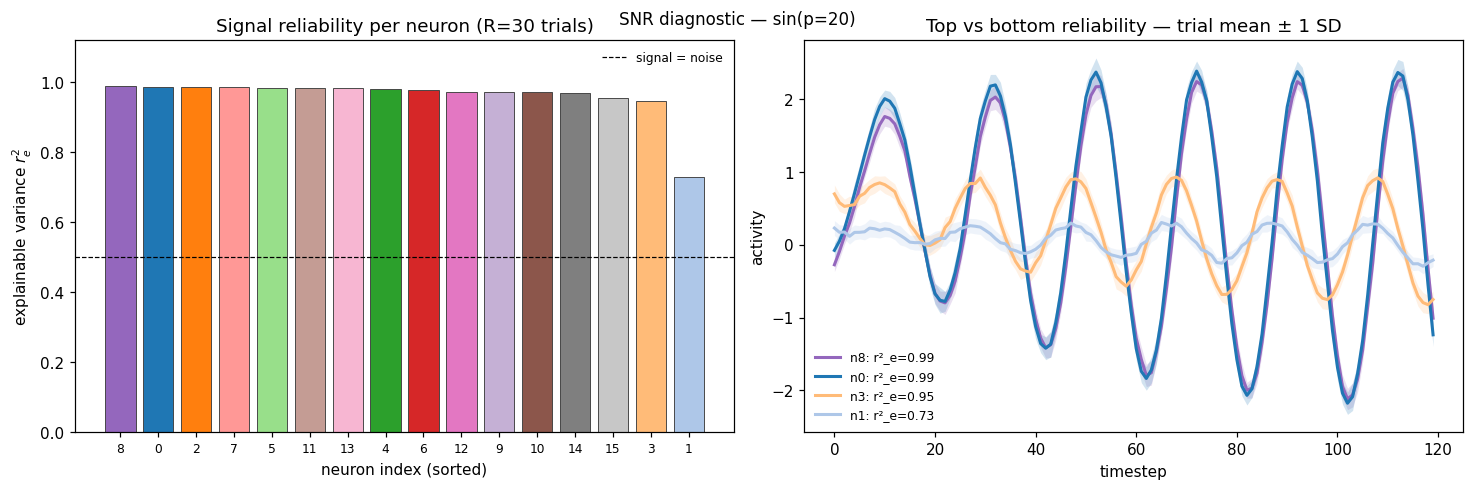

High-SNR neurons: [8 0 2 7]
Low-SNR  neurons: [ 1  3 15 14]


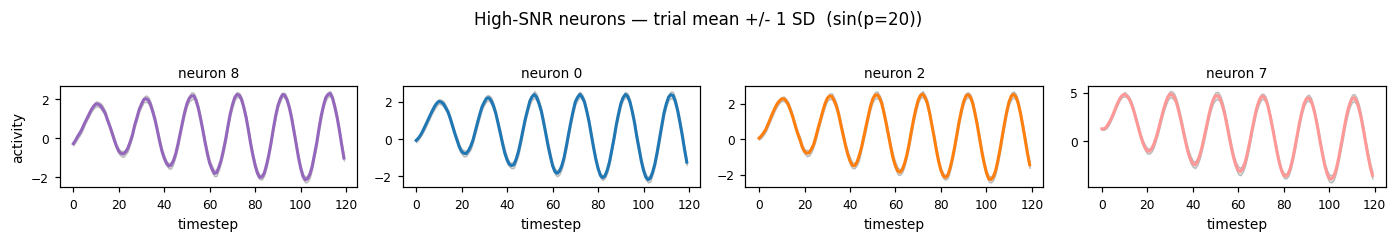

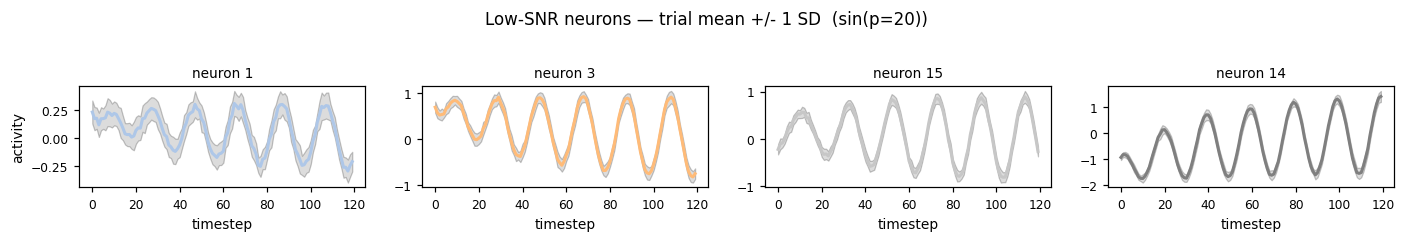

In [35]:
best_cond = max(snr_by_cond, key=lambda c: np.nanmedian(snr_by_cond[c]))
print(f'Highest median SNR condition: "{best_cond}"')

best_trials = sim.simulate_trials(R_trials, T, U=snr_conditions[best_cond])
ill_best    = Illustrator(best_trials['y'])
snr_best, fig = ill_best.compute_snr(plot=True)
fig.suptitle(f'SNR diagnostic — {best_cond}', fontsize=11)
plt.show()

snr_ranked       = np.nan_to_num(snr_best)
high_snr_neurons = np.argsort(snr_ranked)[::-1][:min(4, sim.obs_dim // 2)]
low_snr_neurons  = np.argsort(snr_ranked)[:min(4, sim.obs_dim // 2)]
print(f'High-SNR neurons: {high_snr_neurons}')
print(f'Low-SNR  neurons: {low_snr_neurons}')

fig = ill_best.plot_timeseries(neuron_indices=high_snr_neurons, show_trials=False,
                               title=f'High-SNR neurons — trial mean +/- 1 SD  ({best_cond})')
plt.show()

fig = ill_best.plot_timeseries(neuron_indices=low_snr_neurons, show_trials=False,
                               title=f'Low-SNR neurons — trial mean +/- 1 SD  ({best_cond})')
plt.show()

**What to notice:**
- SNR varies widely across neurons even though C is a random projection — neurons that
  load heavily on high-variance, slowly-decaying modes have far better SNR.
- Sinusoidal input at the natural period typically gives the highest SNR because it
  continuously replenishes signal; under zero input the signal exhausts by ~T/2.
- For `input_aligned_system` and `closed_loop_system`, neurons 0 and 1 should stand
  out as highly informative because their C rows are aligned with the input-driven
  state dimensions — a deliberate design feature.
- High-SNR neurons show a clean mean with a narrow band; low-SNR neurons look noisy
  even at 30 trials. This has direct implications for filtering (Week 2).

---
## 8  Effective Dimensionality

**Question 3 (continued): How many dimensions are actually active?**

With `obs_dim` neurons driven by `state_dim` latent states, the observation covariance
has at most `state_dim` non-trivial eigenvalues. But not all latent modes contribute
equally — the *effective* dimensionality depends on what the input excites.
Comparing sinusoidal vs random input shows this clearly.

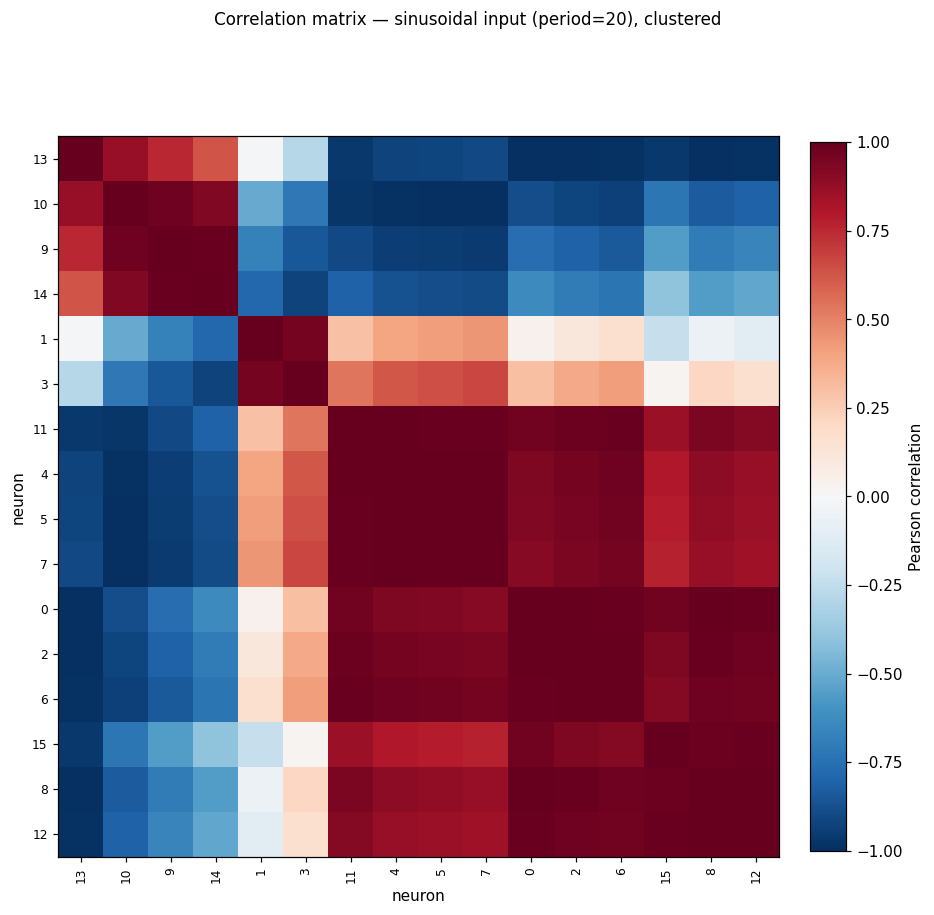

In [36]:
U_sin_res  = sinusoidal_input(T, sim.input_dim, amplitude=0.5, period=float(nat_period))
trials_sin = sim.simulate_trials(R_trials, T, U=U_sin_res)
ill_sin    = Illustrator(trials_sin['y'])

C_mat, fig = ill_sin.plot_correlation_matrix(
    cluster=True,
    title=f'Correlation matrix — sinusoidal input (period={nat_period}), clustered')
plt.show()

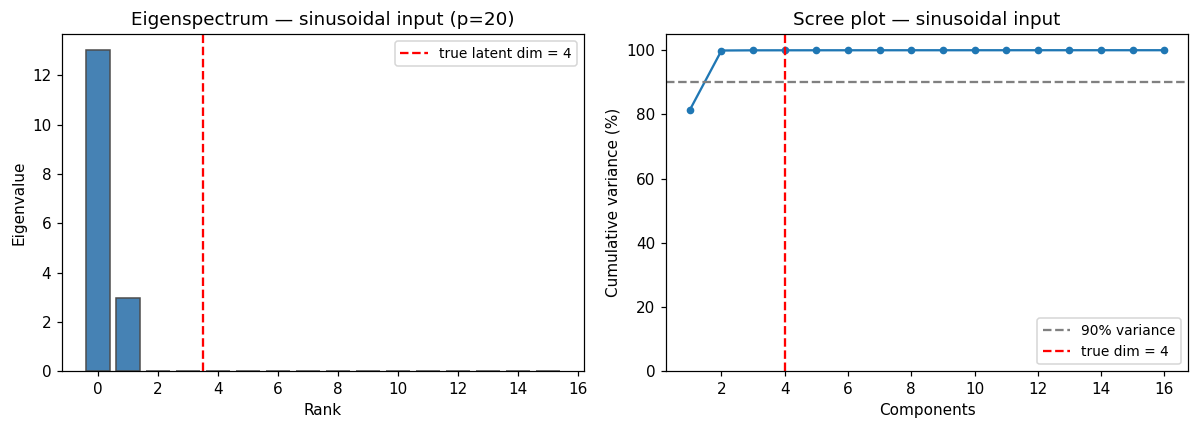

Variance explained by top 4 components: 100.0%


In [37]:
C_uc, _ = ill_sin.plot_correlation_matrix(cluster=False)
plt.close()

eigs   = np.linalg.eigvalsh(C_uc)[::-1]
eigs   = np.clip(eigs, 0, None)
cumvar = np.cumsum(eigs) / eigs.sum()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(range(len(eigs)), eigs, color='steelblue', edgecolor='0.3')
axes[0].axvline(sim.state_dim - 0.5, color='red', ls='--', lw=1.5,
                label=f'true latent dim = {sim.state_dim}')
axes[0].set_xlabel('Rank')
axes[0].set_ylabel('Eigenvalue')
axes[0].set_title(f'Eigenspectrum — sinusoidal input (p={nat_period})')
axes[0].legend(fontsize=9)

axes[1].plot(range(1, len(cumvar) + 1), cumvar * 100, marker='o', ms=4)
axes[1].axhline(90, color='gray', ls='--', label='90% variance')
axes[1].axvline(sim.state_dim, color='red', ls='--',
                label=f'true dim = {sim.state_dim}')
axes[1].set_xlabel('Components')
axes[1].set_ylabel('Cumulative variance (%)')
axes[1].set_title('Scree plot — sinusoidal input')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 105)
plt.tight_layout()
plt.show()

print(f'Variance explained by top {sim.state_dim} components: '
      f'{cumvar[sim.state_dim - 1] * 100:.1f}%')

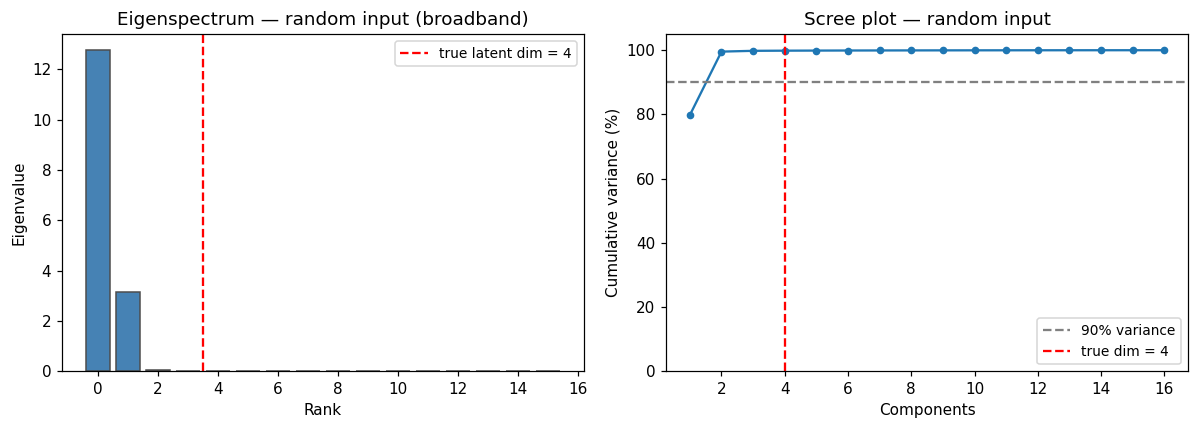

Variance explained by top 4 components (random input): 99.9%
Leading eigenvalues: [1.2766e+01 3.1650e+00 3.9000e-02 8.0000e-03 5.0000e-03 4.0000e-03]


In [38]:
U_rand_dim      = random_input(T, sim.input_dim, amplitude=0.3, seed=42)
trials_rand_dim = sim.simulate_trials(R_trials, T, U=U_rand_dim)
ill_rand_dim    = Illustrator(trials_rand_dim['y'])

C_uc_r, _ = ill_rand_dim.plot_correlation_matrix(cluster=False)
plt.close()

eigs_r   = np.linalg.eigvalsh(C_uc_r)[::-1]
eigs_r   = np.clip(eigs_r, 0, None)
cumvar_r = np.cumsum(eigs_r) / eigs_r.sum()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(range(len(eigs_r)), eigs_r, color='steelblue', edgecolor='0.3')
axes[0].axvline(sim.state_dim - 0.5, color='red', ls='--', lw=1.5,
                label=f'true latent dim = {sim.state_dim}')
axes[0].set_xlabel('Rank')
axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('Eigenspectrum — random input (broadband)')
axes[0].legend(fontsize=9)

axes[1].plot(range(1, len(cumvar_r) + 1), cumvar_r * 100, marker='o', ms=4)
axes[1].axhline(90, color='gray', ls='--', label='90% variance')
axes[1].axvline(sim.state_dim, color='red', ls='--',
                label=f'true dim = {sim.state_dim}')
axes[1].set_xlabel('Components')
axes[1].set_ylabel('Cumulative variance (%)')
axes[1].set_title('Scree plot — random input')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 105)
plt.tight_layout()
plt.show()

print(f'Variance explained by top {sim.state_dim} components (random input): '
      f'{cumvar_r[sim.state_dim - 1] * 100:.1f}%')
print(f'Leading eigenvalues: {np.round(eigs_r[:sim.state_dim + 2], 3)}')

**What to notice:**
- Under sinusoidal input at the natural period, energy concentrates in the resonant
  modes, so the effective dimensionality looks *lower* than the true `state_dim`.
- Random (broadband) input excites all modes more evenly, giving a more honest read of
  the system's full dimensionality — more eigenvalues are non-negligible.
- Modes with very fast decay (small |lam|) remain close to invisible under any input
  because they cannot accumulate variance before decaying.
- The dimensionality you measure depends on what you stimulate with — if you only ever
  drive a network at one frequency, you underestimate its complexity.

---
## 9  What is Easy to Observe, and What is Hidden?

**Question 4: What can be recovered from y alone?**

### What is recoverable

- **Temporal timescales**: oscillation periods and decay half-lives are encoded in the
  ACF of y for any C with non-zero column norms.
- **Shared population structure**: the low-rank correlation matrix approximates the
  latent dimensionality; PCA recovers a rotated version of the active state subspace.
- **Input-pathway fingerprints**: the channel sweep reveals which neurons respond to
  which input channel, exploiting the B → state → C pathway.
- **High-SNR state directions**: states whose variance persistently exceeds the noise
  floor are easy to track in y. High SNR neurons are direct windows onto these directions.

### What is difficult or impossible to recover directly

- **Absolute scale and orientation of x**: C mixes states into all neurons;
  observations identify the state only up to a linear transformation.
- **Fast-decaying modes**: modes with small `|lam|` contribute little to time-averaged
  statistics and are easily buried in observation noise — even if formally observable.
- **Input-driven dims when C is blind to them**: for `input_blind_system`, the
  input-driven dimensions (states 0 and 1) are invisible in y except through
  the attenuated A[2,0] and A[3,1] coupling — a two-hop, low-gain pathway.
- **Single-timestep x**: individual y observations are corrupted by R noise.
  Recovering x(t) from a single trial requires filtering across time —
  exactly what the **Kalman filter (Week 2)** provides.
- **The slow drift** (for `slow_drift_system`): the near-unit-root mode wanders
  far from zero over long trials, making it hard to distinguish signal from
  slow noise without a filter that explicitly tracks this mode.

---
*'Fully observable' is a binary guarantee for infinite noiseless data. The Gramian
condition number (Section 1) quantifies how hard the problem is in practice.
States with contributions persistently above the noise floor are easy to recover;
states whose contribution dips below the floor are effectively hidden, even if
the system is formally observable.*